In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns





In [10]:
df = pd.read_csv(r'D:\customer churn dataanlyst\data\WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [11]:
print(df.shape)        # how many rows/columns
print(df.head())       # first 5 rows
print(df.info())       # data types
print(df.isnull().sum()) # missing values


(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Nulls in TotalCharges: {df['TotalCharges'].isnull().sum()}")
df.dropna(inplace=True)
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f"Cleaned shape: {df.shape}")
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")
df.to_csv(r'D:\customer churn dataanlyst\data\telco_churn_cleaned.csv', index=False)
print("Saved successfully!")

Nulls in TotalCharges: 11
Cleaned shape: (7032, 22)
TotalCharges dtype: float64
Saved successfully!


C:\Users\E N V Y\AppData\Local\Temp\ipykernel_6688\2747486755.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2', ax=axes[0,0])
C:\Users\E N V Y\AppData\Local\Temp\ipykernel_6688\2747486755.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2', ax=axes[0,2])


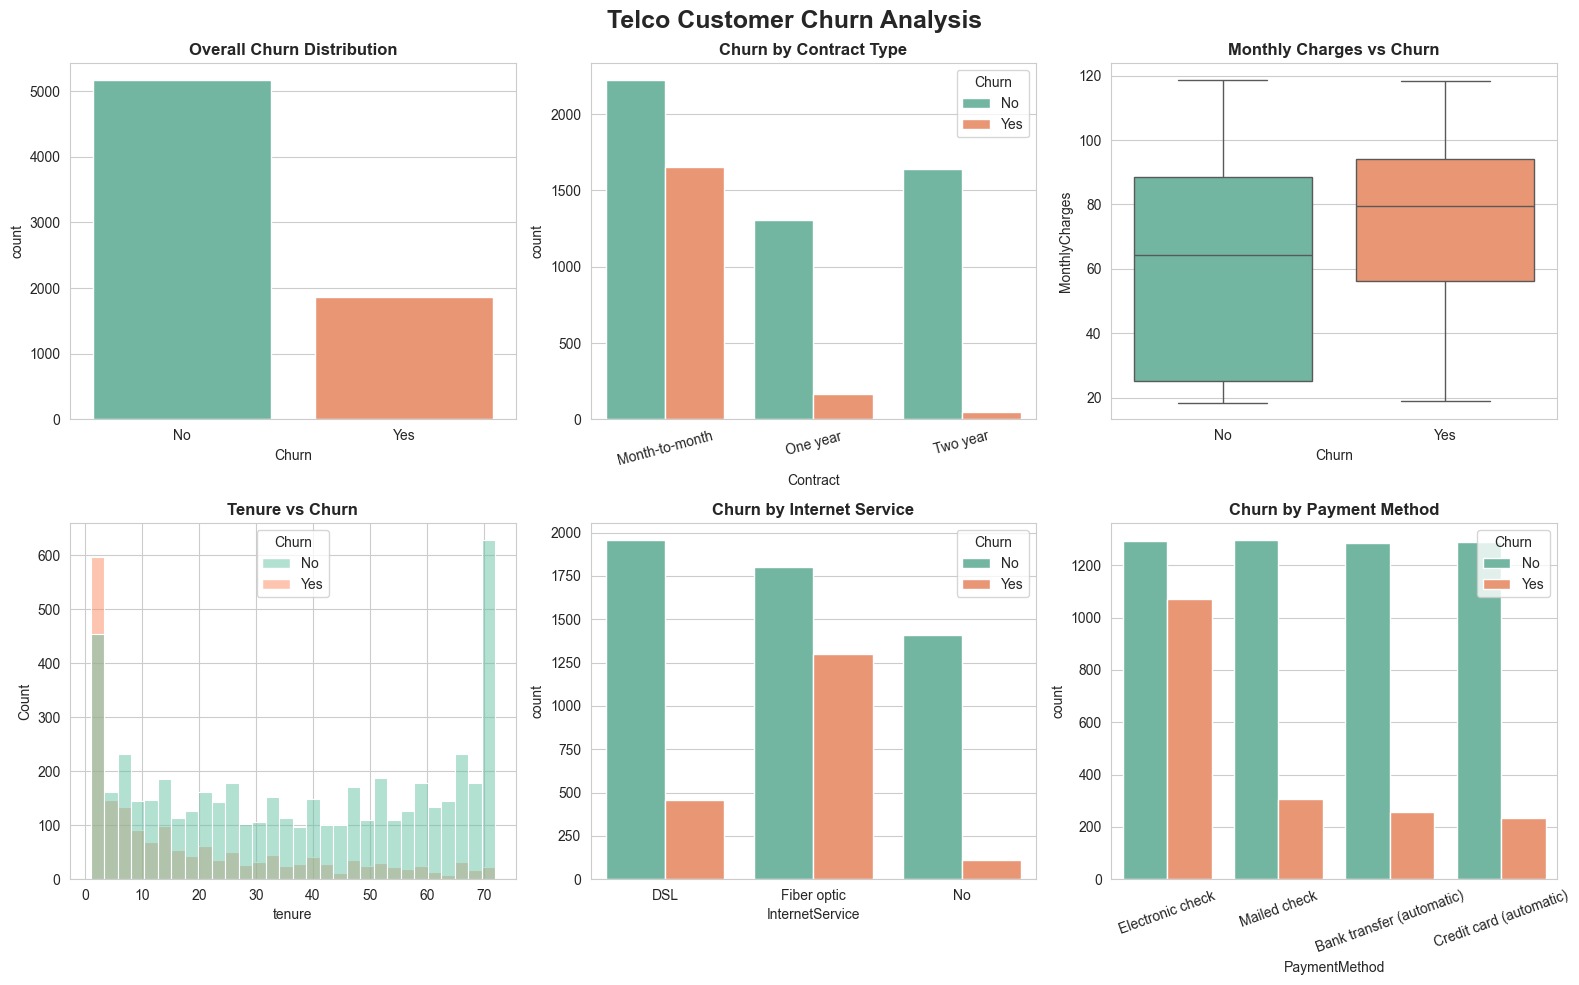

Charts saved!


In [ ]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Telco Customer Churn Analysis', fontsize=18, fontweight='bold')
sns.countplot(data=df, x='Churn', palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Overall Churn Distribution', fontweight='bold')
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2', ax=axes[0,1])
axes[0,1].set_title('Churn by Contract Type', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=15)
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2', ax=axes[0,2])
axes[0,2].set_title('Monthly Charges vs Churn', fontweight='bold')
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette='Set2', ax=axes[1,0])
axes[1,0].set_title('Tenure vs Churn', fontweight='bold')
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Churn by Internet Service', fontweight='bold')
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='Set2', ax=axes[1,2])
axes[1,2].set_title('Churn by Payment Method', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(r'D:\customer churn dataanlyst\visualization\churn_full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved!")

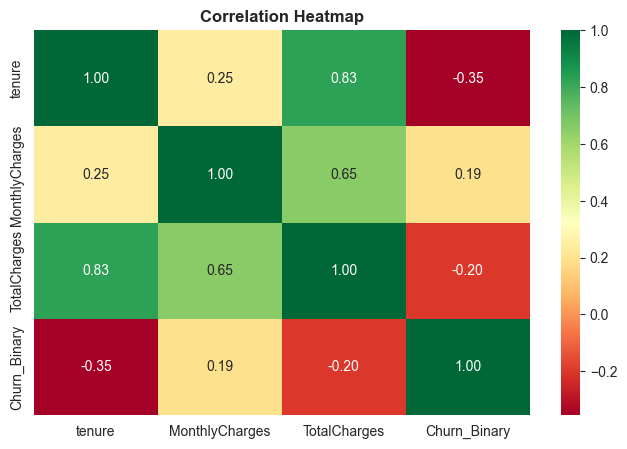

In [15]:
numeric_df = df[['tenure', 'MonthlyCharges', 
                 'TotalCharges', 'Churn_Binary']]

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), 
            annot=True, 
            cmap='RdYlGn',
            fmt='.2f')
plt.title('Correlation Heatmap', 
          fontweight='bold')
plt.savefig(r'D:\customer churn dataanlyst\visualization\heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

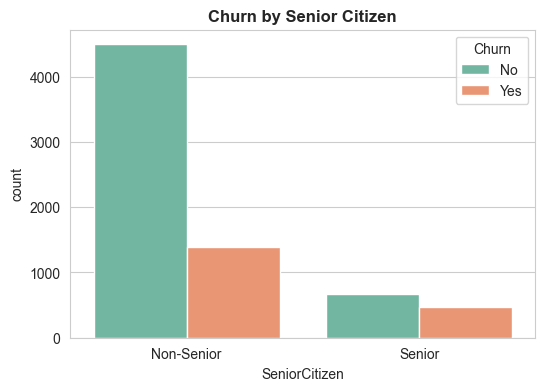

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn', palette='Set2')
plt.title('Churn by Senior Citizen', fontweight='bold')
plt.xticks([0,1], ['Non-Senior', 'Senior'])
plt.savefig(r'D:\customer churn dataanlyst\visualization\senior_churn.png', dpi=150, bbox_inches='tight')
plt.show()

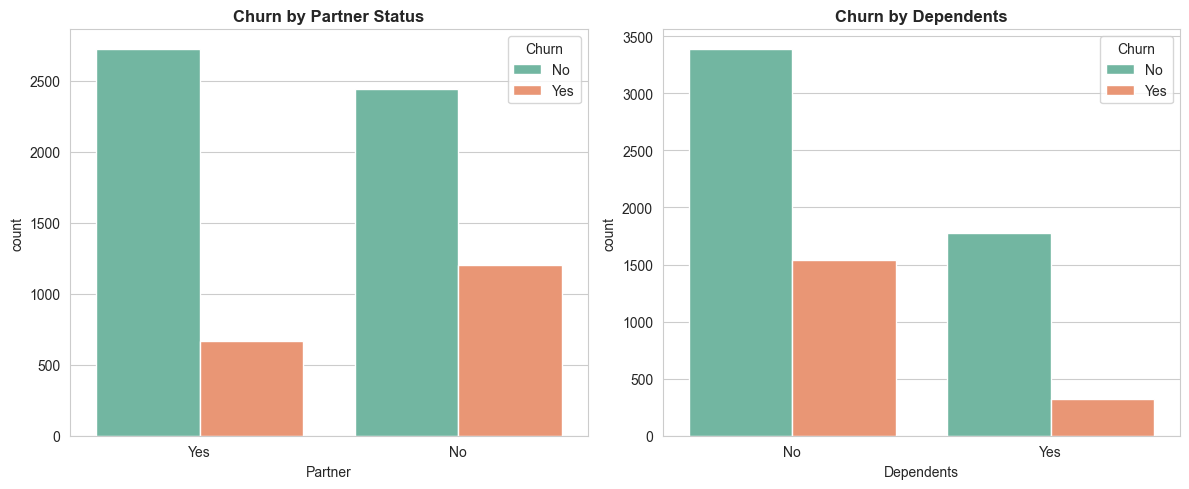

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(data=df, x='Partner', hue='Churn', palette='Set2', ax=axes[0])
axes[0].set_title('Churn by Partner Status', fontweight='bold')
sns.countplot(data=df, x='Dependents', hue='Churn', palette='Set2', ax=axes[1])
axes[1].set_title('Churn by Dependents', fontweight='bold')
plt.tight_layout()
plt.savefig(r'D:\customer churn dataanlyst\visualization\partner_dependents_churn.png', dpi=150, bbox_inches='tight')
plt.show()

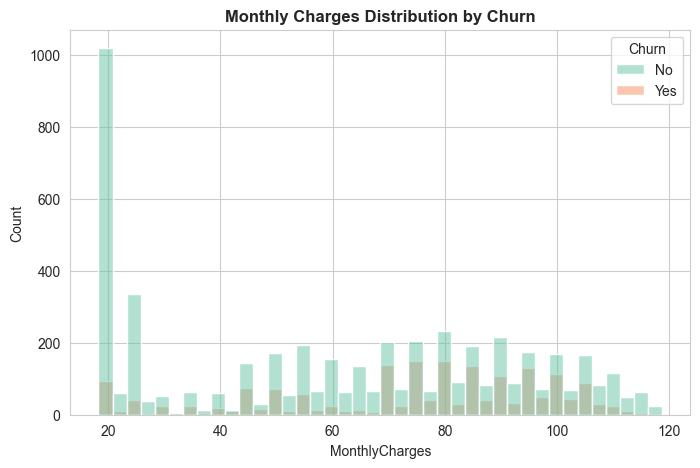

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=40, palette='Set2')
plt.title('Monthly Charges Distribution by Churn', fontweight='bold')
plt.savefig(r'D:\customer churn dataanlyst\visualization\monthly_dist_churn.png', dpi=150, bbox_inches='tight')
plt.show()

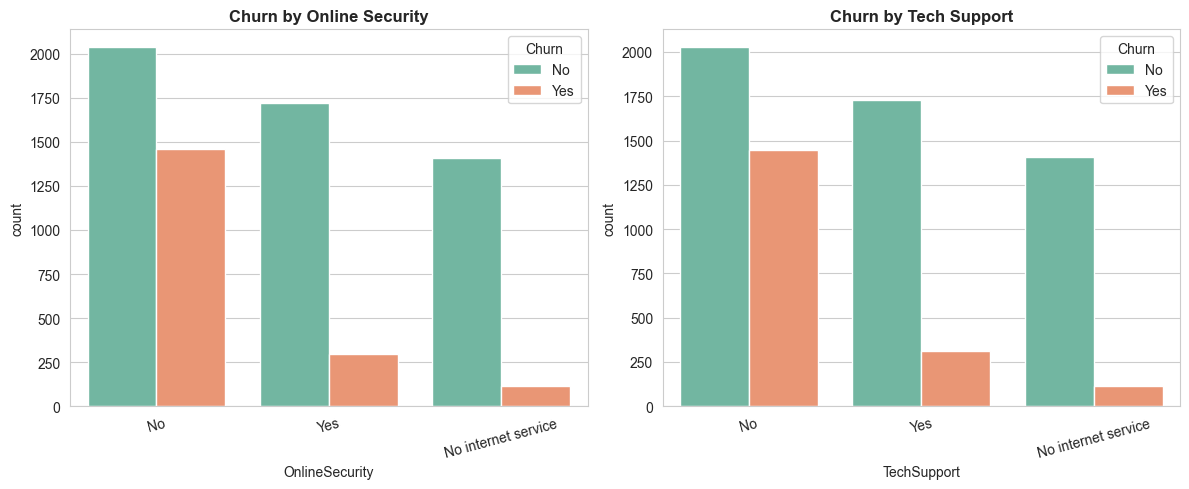

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(data=df, x='OnlineSecurity', hue='Churn', palette='Set2', ax=axes[0])
axes[0].set_title('Churn by Online Security', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
sns.countplot(data=df, x='TechSupport', hue='Churn', palette='Set2', ax=axes[1])
axes[1].set_title('Churn by Tech Support', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(r'D:\customer churn dataanlyst\visualization\security_support_churn.png', dpi=150, bbox_inches='tight')
plt.show()

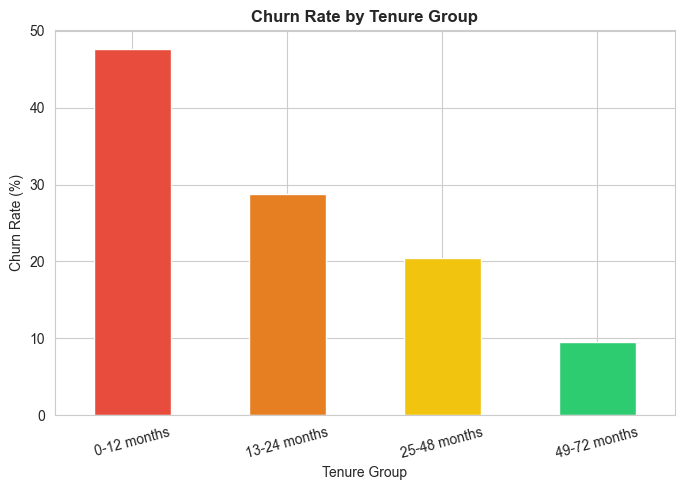

In [21]:
df['Tenure_Group'] = pd.cut(df['tenure'],
                             bins=[0,12,24,48,72],
                             labels=['0-12 months','13-24 months','25-48 months','49-72 months'])
tenure_churn = df.groupby('Tenure_Group', observed=True)['Churn_Binary'].mean() * 100
plt.figure(figsize=(8,5))
tenure_churn.plot(kind='bar', color=['#E74C3C','#E67E22','#F1C40F','#2ECC71'], edgecolor='white')
plt.title('Churn Rate by Tenure Group', fontweight='bold')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.savefig(r'D:\customer churn dataanlyst\visualization\tenure_group_churn.png', dpi=150, bbox_inches='tight')
plt.show()

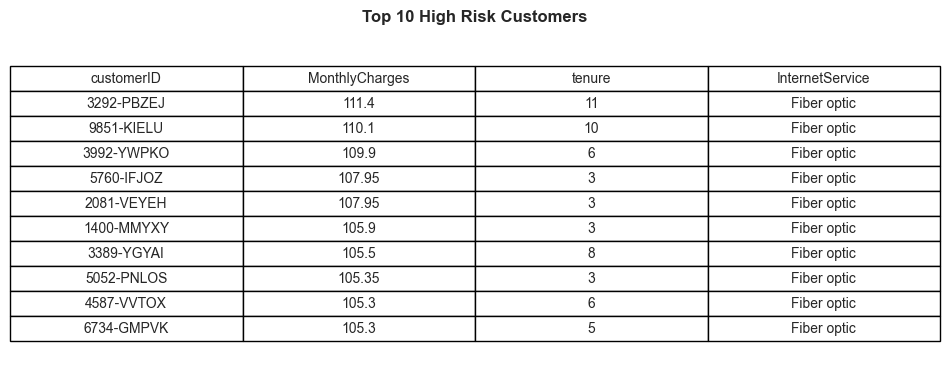

In [22]:
high_risk = df[(df['Contract'] == 'Month-to-month') &
               (df['tenure'] < 12) &
               (df['MonthlyCharges'] > 65)][['customerID','MonthlyCharges','tenure','InternetService']].sort_values('MonthlyCharges', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10,4))
ax.axis('off')
table = ax.table(cellText=high_risk.values,
                 colLabels=high_risk.columns,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title('Top 10 High Risk Customers', fontweight='bold', pad=20)
plt.savefig(r'D:\customer churn dataanlyst\visualization\high_risk_customers.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print("=" * 45)
print("      EXECUTIVE SUMMARY")
print("=" * 45)
print(f"""
PROBLEM  : 26.6% customer churn rate
REVENUE  : $139,131 lost monthly
ROOT CAUSE: Month-to-month contracts (42.7%)
QUICK WIN : Target electronic check users (45.3%)
RETENTION : Push customers to annual contracts
""")
print("=" * 45)

      EXECUTIVE SUMMARY

PROBLEM  : 26.6% customer churn rate
REVENUE  : $139,131 lost monthly
ROOT CAUSE: Month-to-month contracts (42.7%)
QUICK WIN : Target electronic check users (45.3%)
RETENTION : Push customers to annual contracts

